<a href="https://colab.research.google.com/github/zoybathecodess/Battery-Aware-Mars-Rover-DQN-vs-PPO/blob/main/DQN_PPO_Agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
%%writefile rover_env.py
import numpy as np
import random
import heapq
from collections import deque


class RoverEnv:
    def __init__(self, size=10, battery=100):
        self.size = size
        self.max_battery = battery

        self.NORMAL   = 0
        self.SAND     = 1
        self.ROCK     = 2
        self.OBSTACLE = 3

        generator = MarsGridGenerator(size=self.size)
        self.grid, self.start, self.goal = generator.generate()

        self.energy_cost = {
            self.NORMAL:   1,
            self.SAND:     3,
            self.ROCK:     5
        }

        self.reset()

    def generate_terrain(self):
        grid = np.zeros((self.size, self.size))
        for i in range(self.size):
            for j in range(self.size):
                r = random.random()
                if   r < 0.55: grid[i][j] = self.NORMAL
                elif r < 0.70: grid[i][j] = self.SAND
                elif r < 0.85: grid[i][j] = self.ROCK
                else:           grid[i][j] = self.OBSTACLE
        return grid

    def _is_solvable(self):
        visited = set()
        q = deque([(0, 0)])
        visited.add((0, 0))
        while q:
            x, y = q.popleft()
            if (x, y) == self.goal:
                return True
            for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                nx, ny = x+dx, y+dy
                if (0 <= nx < self.size and 0 <= ny < self.size
                        and (nx, ny) not in visited
                        and self.grid[nx][ny] != self.OBSTACLE):
                    visited.add((nx, ny))
                    q.append((nx, ny))
        return False

    def _dijkstra(self, start):
        """
        Compute minimum battery cost from `start` to every reachable cell.
        Returns a dist dict: (x,y) -> min_cost.
        Used for battery-awareness signals.
        """
        dist = {start: 0}
        heap = [(0, start[0], start[1])]
        while heap:
            cost, x, y = heapq.heappop(heap)
            if cost > dist.get((x, y), float('inf')):
                continue
            for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                nx, ny = x+dx, y+dy
                if 0 <= nx < self.size and 0 <= ny < self.size:
                    if self.grid[nx][ny] != self.OBSTACLE:
                        nc = cost + self.energy_cost.get(self.grid[nx][ny], 1)
                        if nc < dist.get((nx,ny), float('inf')):
                            dist[(nx,ny)] = nc
                            heapq.heappush(heap, (nc, nx, ny))
        return dist

    def reset(self):
        self.start = (0, 0)
        self.goal  = (self.size - 1, self.size - 1)

        for _ in range(200):
            self.grid = self.generate_terrain()
            self.grid[self.start] = self.NORMAL
            self.grid[self.goal]  = self.NORMAL
            for di in range(2):
                for dj in range(2):
                    if self.grid[di][dj] == self.OBSTACLE:
                        self.grid[di][dj] = self.NORMAL
                    gi, gj = self.size-1-di, self.size-1-dj
                    if self.grid[gi][gj] == self.OBSTACLE:
                        self.grid[gi][gj] = self.NORMAL
            if self._is_solvable():
                break

        self.position = list(self.start)
        self.battery  = self.max_battery
        self.steps    = 0

        # Pre-compute optimal cost from start to goal for the episode
        dist = self._dijkstra(self.start)
        self.optimal_cost = dist.get(self.goal, self.max_battery)

        return self.get_state()

    def _get_battery_awareness_signals(self):
        """
        ── BATTERY-AWARENESS BLOCK ──────────────────────────────────────────
        Computes three signals that together let the agent reason about
        whether it has enough energy to complete the mission:

        1. battery_ratio      — raw battery remaining (normalised)
        2. cost_to_goal_ratio — minimum cost to reach goal from here
                                (normalised by max_battery)
        3. budget_margin      — surplus/deficit relative to what is needed:
                                > 0  → agent has more than enough battery
                                = 0  → agent has exactly enough
                                < 0  → agent CANNOT reach goal (critical)

        These three numbers together form the "battery budget" the agent
        can use to decide whether to take a risky short route through rock
        or a safer long route through normal terrain.
        ─────────────────────────────────────────────────────────────────────
        """
        pos = tuple(self.position)

        # Minimum battery cost from current position to goal
        dist_from_here = self._dijkstra(pos)
        min_cost_to_goal = dist_from_here.get(self.goal, self.max_battery)

        battery_ratio      = self.battery / self.max_battery
        cost_to_goal_ratio = min_cost_to_goal / self.max_battery

        # budget_margin > 0: surplus; < 0: agent is stranded
        budget_margin = (self.battery - min_cost_to_goal) / self.max_battery

        return battery_ratio, cost_to_goal_ratio, budget_margin

    def get_state(self):
        """
        17-dimensional state vector:
          [0]   norm_x              — position x (normalised)
          [1]   norm_y              — position y (normalised)
          [2]   goal_dx             — x distance to goal (normalised)
          [3]   goal_dy             — y distance to goal (normalised)
          [4]   battery_ratio       — battery remaining / max_battery
          [5]   cost_to_goal_ratio  — min cost to goal / max_battery  ← NEW
          [6]   budget_margin       — (battery - min_cost) / max_battery ← NEW
          [7]   steps_ratio         — steps taken / max_battery  ← NEW
          [8-16] 3x3 terrain patch  — local terrain visibility
        """
        x, y = self.position
        norm_x = x / (self.size - 1)
        norm_y = y / (self.size - 1)
        dx = (self.goal[0] - x) / (self.size - 1)
        dy = (self.goal[1] - y) / (self.size - 1)

        # Battery-awareness signals
        battery_ratio, cost_to_goal_ratio, budget_margin = \
            self._get_battery_awareness_signals()

        # Steps taken as fraction of battery budget
        steps_ratio = self.steps / self.max_battery

        # 3x3 local terrain patch
        patch = []
        for di in [-1, 0, 1]:
            for dj in [-1, 0, 1]:
                ni, nj = x + di, y + dj
                if 0 <= ni < self.size and 0 <= nj < self.size:
                    t = self.grid[ni][nj]
                    if   t == self.OBSTACLE: patch.append(1.0)
                    elif t == self.ROCK:     patch.append(0.6)
                    elif t == self.SAND:     patch.append(0.3)
                    else:                    patch.append(0.0)
                else:
                    patch.append(1.0)

        return np.array(
            [norm_x, norm_y, dx, dy,
             battery_ratio, cost_to_goal_ratio, budget_margin, steps_ratio]
            + patch,
            dtype=float
        )

    def step(self, action):
        x, y = self.position
        self.steps += 1

        nx, ny = x, y
        if   action == 0: nx -= 1
        elif action == 1: nx += 1
        elif action == 2: ny -= 1
        elif action == 3: ny += 1

        nx = max(0, min(self.size - 1, nx))
        ny = max(0, min(self.size - 1, ny))

        # Obstacle collision
        if self.grid[nx][ny] == self.OBSTACLE:
            self.battery -= 1
            if self.battery <= 0:
                return self.get_state(), -10, True
            return self.get_state(), -2, False

        self.position = [nx, ny]
        terrain = self.grid[nx][ny]
        step_cost = self.energy_cost.get(terrain, 1)
        self.battery -= step_cost

        # ── BATTERY-AWARE REWARD SHAPING ─────────────────────────────────────
        # Standard proximity reward
        old_dist = abs(x - self.goal[0]) + abs(y - self.goal[1])
        new_dist = abs(nx - self.goal[0]) + abs(ny - self.goal[1])

        # reward for moving closer to goal
        reward = (old_dist - new_dist) * 0.5

        # small step penalty to encourage efficiency
        reward -= 0.05

        # Terrain penalty
        if terrain == self.SAND: reward -= 0.05
        if terrain == self.ROCK: reward -= 0.1

        # Budget margin penalty — penalise the agent when it is burning
        # battery faster than needed, proportional to how deep into deficit
        # it is going. This is the core battery-awareness shaping term.
        _, _, budget_margin = self._get_battery_awareness_signals()

        if budget_margin < 0:
            # Agent no longer has enough battery to reach goal optimally —
            # scale penalty by how deep the deficit is
            reward += 0.5 * budget_margin   # budget_margin is negative here

        elif budget_margin < 0.1:
            # Danger zone: cutting it very close — mild warning
            reward -= 0.2

        # ─────────────────────────────────────────────────────────────────────

        # Goal reached
        if (nx, ny) == self.goal:
            # Efficiency bonus: reward proportional to remaining battery
            # relative to the optimal cost — not just raw battery remaining.
            # This rewards finding near-optimal paths, not just any path.
            efficiency = (self.battery / self.optimal_cost)
            efficiency = min(efficiency, 1.0)   # cap at 1.0
            return self.get_state(), 100 + 50 * efficiency, True

        # Battery exhausted
        if self.battery <= 0:
            return self.get_state(), -20, True

        return self.get_state(), reward, False

    def render(self):
        g = np.zeros((self.size, self.size))
        for i in range(self.size):
            for j in range(self.size):
                if   self.grid[i][j] == self.OBSTACLE: g[i][j] = -1
                elif self.grid[i][j] == self.SAND:     g[i][j] =  0.5
                elif self.grid[i][j] == self.ROCK:     g[i][j] =  0.7
        g[self.goal[0]][self.goal[1]]         = 2
        g[self.position[0]][self.position[1]] = 1
        print(g)

Overwriting rover_env.py


In [2]:
%%writefile dqn_agent.py
import numpy as np
import random
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim


class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, x):
        return self.net(x)


class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size  = state_size
        self.action_size = action_size

        self.memory = deque(maxlen=50000)

        self.gamma         = 0.99
        self.epsilon       = 1.0
        self.epsilon_min   = 0.05
        self.epsilon_decay = 0.992

        self.learning_rate = 0.0005

        self.model        = DQN(state_size, action_size)
        self.target_model = DQN(state_size, action_size)
        self.update_target_network()

        self.optimizer = optim.Adam(self.model.parameters(),
                                    lr=self.learning_rate, eps=1e-4)
        self.criterion = nn.SmoothL1Loss()

        self.train_step         = 0
        self.target_update_freq = 500

    def update_target_network(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state_t = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.model(state_t)
        return torch.argmax(q_values).item()

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return

        minibatch = random.sample(self.memory, batch_size)

        states      = torch.FloatTensor(np.array([m[0] for m in minibatch]))
        actions     = torch.LongTensor( [m[1] for m in minibatch])
        rewards     = torch.FloatTensor([m[2] for m in minibatch])
        next_states = torch.FloatTensor(np.array([m[3] for m in minibatch]))
        dones       = torch.FloatTensor([m[4] for m in minibatch])

        # Double DQN
        with torch.no_grad():
            best_actions = self.model(next_states).argmax(1, keepdim=True)
            next_q = self.target_model(next_states).gather(1, best_actions).squeeze(1)

        target_q  = rewards + self.gamma * next_q * (1 - dones)
        current_q = self.model(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        loss = self.criterion(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()

        self.train_step += 1
        if self.train_step % self.target_update_freq == 0:
            self.update_target_network()

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

Writing dqn_agent.py


State size: 17  (expected 17)
Warming up replay buffer...
Warmup done. Buffer: 2000, state dim: 17

Ep    1/1500 | R:   -33.5 | ε: 0.992 | SR(100): 0.00 | Avg battery left: 0.0
Ep    2/1500 | R:   -40.7 | ε: 0.984 | SR(100): 0.00 | Avg battery left: -1.0
Ep    3/1500 | R:   -33.0 | ε: 0.976 | SR(100): 0.00 | Avg battery left: -0.7
Ep    4/1500 | R:   -53.4 | ε: 0.968 | SR(100): 0.00 | Avg battery left: -0.8
Ep    5/1500 | R:   -18.7 | ε: 0.961 | SR(100): 0.00 | Avg battery left: -0.6
Ep    6/1500 | R:   -35.3 | ε: 0.953 | SR(100): 0.00 | Avg battery left: -0.5
Ep    7/1500 | R:   -21.3 | ε: 0.945 | SR(100): 0.00 | Avg battery left: -0.7
Ep    8/1500 | R:   -29.3 | ε: 0.938 | SR(100): 0.00 | Avg battery left: -0.8
Ep    9/1500 | R:   -40.5 | ε: 0.930 | SR(100): 0.00 | Avg battery left: -0.7
Ep   10/1500 | R:   -19.9 | ε: 0.923 | SR(100): 0.00 | Avg battery left: -0.6
Ep   11/1500 | R:   -28.9 | ε: 0.915 | SR(100): 0.00 | Avg battery left: -0.5
Ep   12/1500 | R:   -32.6 | ε: 0.908 | SR(1

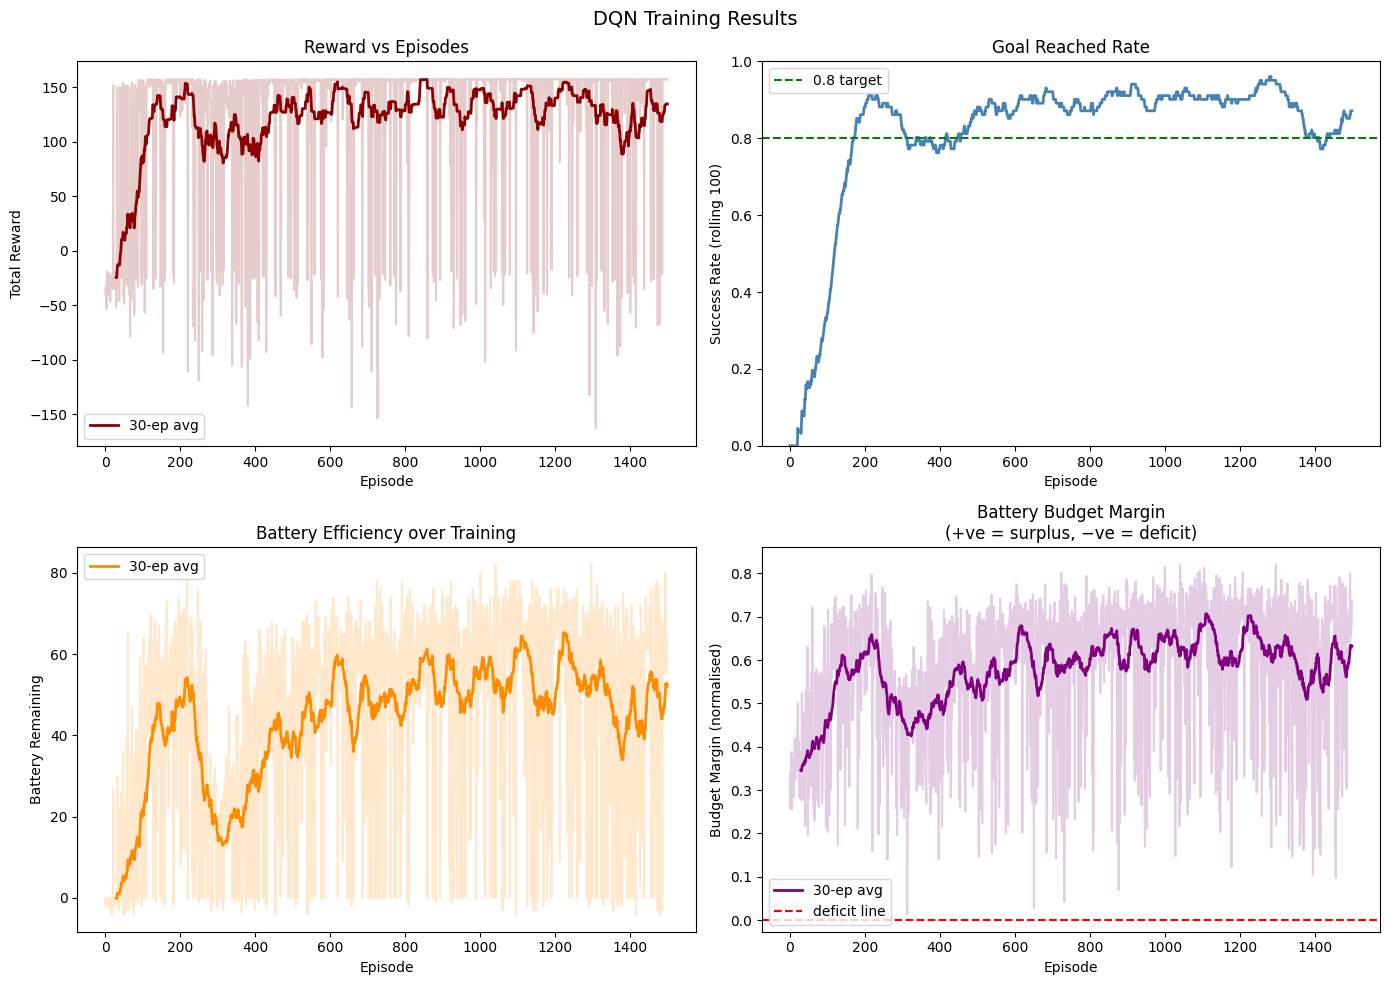


Final success rate     (last 100 ep): 0.87
Avg battery remaining  (last 100 ep): 48.6
Avg budget margin      (last 100 ep): 0.598


In [12]:
import importlib, sys
for mod in ["rover_env", "dqn_agent"]:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

from rover_env import RoverEnv
from dqn_agent import DQNAgent
import numpy as np
import matplotlib.pyplot as plt

env = RoverEnv()

_probe      = env.reset()
state_size  = len(_probe)        # 17
action_size = 4
print(f"State size: {state_size}  (expected 17)")
assert state_size == 17, \
    f"Got {state_size} — re-run Cell 1 and Cell 2 first, then restart runtime."

agent = DQNAgent(state_size, action_size)

episodes   = 1500
batch_size = 128

reward_history   = []
success_history  = []
battery_history  = []   # track battery remaining at end of each episode
margin_history   = []   # track budget margin over time

# Warmup
print("Warming up replay buffer...")
state = env.reset()
for _ in range(2000):
    action = np.random.randint(action_size)
    next_state, reward, done = env.step(action)
    agent.remember(state, action, reward, next_state, done)
    state = next_state if not done else env.reset()
print(f"Warmup done. Buffer: {len(agent.memory)}, state dim: {len(agent.memory[0][0])}\n")

for e in range(episodes):
    state        = env.reset()
    total_reward = 0
    reached_goal = False
    ep_margins   = []

    for _ in range(env.max_battery):
        action = agent.act(state)
        next_state, reward, done = env.step(action)

        # Log budget_margin (index 6 in state vector) each step
        ep_margins.append(next_state[6])

        agent.remember(state, action, reward, next_state, done)
        state        = next_state
        total_reward += reward

        if len(agent.memory) > batch_size:
            agent.replay(batch_size)

        if done:
            if reward >= 100:
                reached_goal = True
            break

    agent.decay_epsilon()

    reward_history.append(total_reward)
    success_history.append(1 if reached_goal else 0)
    battery_history.append(env.battery)
    margin_history.append(np.mean(ep_margins))

    recent_sr  = (np.mean(success_history[-100:]) if len(success_history) >= 100
                  else np.mean(success_history))
    recent_bat = (np.mean(battery_history[-100:]) if len(battery_history) >= 100
                  else np.mean(battery_history))

    print(f"Ep {e+1:4d}/{episodes} | R: {total_reward:7.1f} | "
          f"ε: {agent.epsilon:.3f} | SR(100): {recent_sr:.2f} | "
          f"Avg battery left: {recent_bat:.1f}")


# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("DQN Training Results", fontsize=14)

window = 30

# 1. Reward vs Episodes
smoothed_r = np.convolve(reward_history, np.ones(window)/window, mode='valid')
axes[0,0].plot(reward_history, alpha=0.2, color="darkred")
axes[0,0].plot(range(window-1, len(reward_history)), smoothed_r,
               color="darkred", lw=2, label=f"{window}-ep avg")
axes[0,0].set_xlabel("Episode")
axes[0,0].set_ylabel("Total Reward")
axes[0,0].set_title("Reward vs Episodes")
axes[0,0].legend()

# 2. Success Rate
rolling_sr = [np.mean(success_history[max(0,i-100):i+1])
              for i in range(len(success_history))]
axes[0,1].plot(rolling_sr, color="steelblue", lw=2)
axes[0,1].axhline(0.8, color="green", linestyle="--", label="0.8 target")
axes[0,1].set_xlabel("Episode")
axes[0,1].set_ylabel("Success Rate (rolling 100)")
axes[0,1].set_title("Goal Reached Rate")
axes[0,1].set_ylim(0, 1)
axes[0,1].legend()

# 3. Battery Remaining at Episode End
smoothed_b = np.convolve(battery_history, np.ones(window)/window, mode='valid')
axes[1,0].plot(battery_history, alpha=0.2, color="darkorange")
axes[1,0].plot(range(window-1, len(battery_history)), smoothed_b,
               color="darkorange", lw=2, label=f"{window}-ep avg")
axes[1,0].set_xlabel("Episode")
axes[1,0].set_ylabel("Battery Remaining")
axes[1,0].set_title("Battery Efficiency over Training")
axes[1,0].legend()

# 4. Budget Margin over Training
smoothed_m = np.convolve(margin_history, np.ones(window)/window, mode='valid')
axes[1,1].plot(margin_history, alpha=0.2, color="purple")
axes[1,1].plot(range(window-1, len(margin_history)), smoothed_m,
               color="purple", lw=2, label=f"{window}-ep avg")
axes[1,1].axhline(0, color="red", linestyle="--", label="deficit line")
axes[1,1].set_xlabel("Episode")
axes[1,1].set_ylabel("Budget Margin (normalised)")
axes[1,1].set_title("Battery Budget Margin\n(+ve = surplus, −ve = deficit)")
axes[1,1].legend()

plt.tight_layout()
plt.savefig("DQN_Training_Results.png", dpi=150)
plt.show()

print(f"\nFinal success rate     (last 100 ep): {np.mean(success_history[-100:]):.2f}")
print(f"Avg battery remaining  (last 100 ep): {np.mean(battery_history[-100:]):.1f}")
print(f"Avg budget margin      (last 100 ep): {np.mean(margin_history[-100:]):.3f}")



In [4]:
%%writefile ppo_agent.py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical


class ActorCritic(nn.Module):
    def __init__(self, state_size, action_size):
        super(ActorCritic, self).__init__()

        self.shared = nn.Sequential(
            nn.Linear(state_size, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
        )

        # FIX 1: output raw LOGITS, not Softmax probabilities
        # Categorical(logits=...) is numerically stable; Softmax+Categorical is not
        self.actor = nn.Sequential(
            nn.Linear(256, 128),
            nn.Tanh(),
            nn.Linear(128, action_size)   # no Softmax here
        )

        self.critic = nn.Sequential(
            nn.Linear(256, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        # Orthogonal weight init — standard best practice for PPO
        for layer in self.modules():
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        shared = self.shared(x)
        logits = self.actor(shared)   # raw logits
        value  = self.critic(shared)
        return logits, value

    def act(self, state):
        state_t        = torch.FloatTensor(state).unsqueeze(0)
        logits, value  = self.forward(state_t)
        dist           = Categorical(logits=logits)  # FIX 1 continued
        action         = dist.sample()
        return action.item(), dist.log_prob(action), value


class PPOAgent:
    def __init__(self, state_size, action_size):
        self.state_size  = state_size
        self.action_size = action_size

        self.gamma        = 0.99
        self.gae_lambda   = 0.95
        self.eps_clip     = 0.2
        # FIX 2: more gradient steps per rollout — 4 was too few
        self.K_epochs     = 10
        # FIX 3: higher entropy coefficient forces more exploration early on
        self.entropy_coef = 0.05

        self.model     = ActorCritic(state_size, action_size)
        self.optimizer = optim.Adam(self.model.parameters(),
                                    lr=3e-4, eps=1e-5)
        self.criterion = nn.MSELoss()

        # Rollout buffer
        self.states    = []
        self.actions   = []
        self.log_probs = []
        self.rewards   = []
        self.values    = []
        self.dones     = []

    def act(self, state):
        action, log_prob, value = self.model.act(state)
        return action, log_prob, value

    def store(self, state, action, log_prob, reward, value, done):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.values.append(value.item())
        self.dones.append(done)

    def _compute_gae(self, next_value):
        advantages = []
        gae    = 0
        values = self.values + [next_value]
        for t in reversed(range(len(self.rewards))):
            delta = (self.rewards[t]
                     + self.gamma * values[t+1] * (1 - self.dones[t])
                     - values[t])
            gae   = delta + self.gamma * self.gae_lambda * (1 - self.dones[t]) * gae
            advantages.insert(0, gae)
        returns = [a + v for a, v in zip(advantages, self.values)]
        return advantages, returns

    def update(self, next_value=0.0):
        advantages, returns = self._compute_gae(next_value)

        states       = torch.FloatTensor(np.array(self.states))
        actions      = torch.LongTensor(self.actions)
        old_lps      = torch.stack(self.log_probs).detach()
        advantages_t = torch.FloatTensor(advantages)
        returns_t    = torch.FloatTensor(returns)

        advantages_t = (advantages_t - advantages_t.mean()) / \
                       (advantages_t.std() + 1e-8)

        n = len(self.states)
        for _ in range(self.K_epochs):
            # FIX 4: mini-batch updates within each epoch for better gradient estimates
            indices = np.random.permutation(n)
            for start in range(0, n, 64):
                idx = indices[start:start+64]

                logits, values = self.model(states[idx])
                dist     = Categorical(logits=logits)
                new_lps  = dist.log_prob(actions[idx])
                entropy  = dist.entropy().mean()

                ratios = torch.exp(new_lps - old_lps[idx])
                surr1  = ratios * advantages_t[idx]
                surr2  = torch.clamp(ratios,
                                     1 - self.eps_clip,
                                     1 + self.eps_clip) * advantages_t[idx]
                actor_loss  = -torch.min(surr1, surr2).mean()
                critic_loss = self.criterion(values.squeeze(), returns_t[idx])

                loss = actor_loss + 0.5 * critic_loss - self.entropy_coef * entropy

                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.5)
                self.optimizer.step()

        # Clear buffer
        self.states, self.actions, self.log_probs = [], [], []
        self.rewards, self.values, self.dones      = [], [], []

Writing ppo_agent.py


In [5]:
import pickle

dqn_results = {
    "rewards": reward_history,
    "success": success_history,
    "battery": battery_history,
    "margins": margin_history,
    "steps":   [env.max_battery] * len(reward_history)  # placeholder
}
with open("dqn_results.pkl", "wb") as f:
    pickle.dump(dqn_results, f)

print("DQN results saved.")

DQN results saved.


In [6]:
%%writefile ppo_agent.py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical


class ActorCritic(nn.Module):
    def __init__(self, state_size, action_size):
        super(ActorCritic, self).__init__()

        # FIX 1: wider network — 128 is too small for a 17-dim battery-aware state
        self.shared = nn.Sequential(
            nn.Linear(state_size, 256),
            nn.Tanh(),          # FIX 2: Tanh over ReLU for PPO — smoother gradients,
            nn.Linear(256, 256),# less likely to produce dead neurons in policy head
            nn.Tanh()
        )

        self.actor  = nn.Linear(256, action_size)
        self.critic = nn.Linear(256, 1)

        # FIX 3: orthogonal init — standard PPO best practice
        # makes critic produce reasonable value estimates from episode 1
        for layer in self.modules():
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                nn.init.zeros_(layer.bias)

    def forward(self, state):
        x = self.shared(state)
        return self.actor(x), self.critic(x)


class PPOAgent:
    def __init__(self, state_size, action_size):

        self.gamma        = 0.99
        self.lam          = 0.95
        self.clip         = 0.2
        self.lr           = 3e-4
        self.epochs       = 10       # FIX 4: more epochs per rollout (was 5)
        # FIX 5: higher entropy — forces exploration on sparse reward env
        # 0.01 is too low; agent collapses to deterministic policy too fast
        self.entropy_coef = 0.05
        self.value_coef   = 0.5

        self.model     = ActorCritic(state_size, action_size)
        self.optimizer = optim.Adam(self.model.parameters(),
                                    lr=self.lr, eps=1e-5)
        self.reset_memory()

    def reset_memory(self):
        self.states    = []
        self.actions   = []
        self.log_probs = []
        self.rewards   = []
        self.values    = []
        self.dones     = []

    def act(self, state):
        state_t = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            logits, value = self.model(state_t)
        dist     = Categorical(logits=logits)
        action   = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob.item(), value.item()

    def store(self, state, action, log_prob, reward, value, done):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.values.append(value)
        self.dones.append(done)

    def compute_gae(self, next_value):
        values = self.values + [next_value]
        gae    = 0
        returns = []

        for step in reversed(range(len(self.rewards))):
            delta = (
                self.rewards[step]
                + self.gamma * values[step + 1] * (1 - self.dones[step])
                - values[step]
            )
            gae = delta + self.gamma * self.lam * (1 - self.dones[step]) * gae
            returns.insert(0, gae + values[step])

        advantages = np.array(returns) - np.array(self.values)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        return returns, advantages

    def update(self, next_value):
        returns, advantages = self.compute_gae(next_value)

        states       = torch.FloatTensor(np.array(self.states))
        actions      = torch.LongTensor(self.actions)
        old_log_probs = torch.FloatTensor(self.log_probs)
        returns_t    = torch.FloatTensor(returns)
        advantages_t = torch.FloatTensor(advantages)

        # FIX 6: mini-batch updates within each epoch
        # full-batch updates on large rollouts destabilise training
        n = len(self.states)
        batch_size = 64

        for _ in range(self.epochs):
            indices = np.random.permutation(n)
            for start in range(0, n, batch_size):
                idx = indices[start:start + batch_size]

                logits, values = self.model(states[idx])
                dist       = Categorical(logits=logits)
                new_lp     = dist.log_prob(actions[idx])
                entropy    = dist.entropy().mean()

                ratio = (new_lp - old_log_probs[idx]).exp()
                surr1 = ratio * advantages_t[idx]
                surr2 = torch.clamp(ratio,
                                    1 - self.clip,
                                    1 + self.clip) * advantages_t[idx]

                actor_loss  = -torch.min(surr1, surr2).mean()
                critic_loss = (returns_t[idx] - values.squeeze()).pow(2).mean()
                loss = (actor_loss
                        + self.value_coef * critic_loss
                        - self.entropy_coef * entropy)

                self.optimizer.zero_grad()
                loss.backward()
                # FIX 7: gradient clipping — missing from your version
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.5)
                self.optimizer.step()

        self.reset_memory()

Overwriting ppo_agent.py


In [11]:
import importlib, sys
for mod in ["rover_env", "ppo_agent"]:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

from rover_env import RoverEnv
from ppo_agent import PPOAgent
import numpy as np
import pickle
import torch

env = RoverEnv()
_probe     = env.reset()
state_size = len(_probe)
assert state_size == 17, f"State size {state_size} != 17. Re-run Cell 1."
print(f"PPO Training | state_size={state_size}")

agent = PPOAgent(state_size, action_size=4)

episodes = 1500

# KEY FIX: update every 512 steps (~8-10 episodes)
# too small (256) = noisy gradients, too large (2048) = no signal
UPDATE_EVERY = 512

ppo_rewards = []
ppo_success = []
ppo_battery = []
ppo_margins = []
ppo_steps   = []

global_step   = 0
state         = env.reset()
ep_reward     = 0
ep_margins    = []
ep_steps      = 0
reached_goal  = False
episodes_done = 0

print("Starting PPO training...\n")

while episodes_done < episodes:

    action, log_prob, value = agent.act(state)
    next_state, reward, done = env.step(action)

    ep_margins.append(next_state[6])
    ep_steps  += 1
    ep_reward += reward
    global_step += 1

    agent.store(state, action, log_prob, reward, value, float(done))
    state = next_state

    if done:
        if reward >= 100:
            reached_goal = True

        ppo_rewards.append(ep_reward)
        ppo_success.append(1 if reached_goal else 0)
        ppo_battery.append(env.battery)
        ppo_margins.append(np.mean(ep_margins) if ep_margins else 0)
        ppo_steps.append(ep_steps)

        episodes_done += 1
        sr = (np.mean(ppo_success[-100:]) if len(ppo_success) >= 100
              else np.mean(ppo_success))
        print(f"PPO Ep {episodes_done:4d}/{episodes} | R:{ep_reward:7.1f} | "
              f"SR:{sr:.2f} | Bat:{env.battery:3d} | Steps:{ep_steps}")

        state        = env.reset()
        ep_reward    = 0
        ep_margins   = []
        ep_steps     = 0
        reached_goal = False

    if global_step % UPDATE_EVERY == 0 and len(agent.states) > 0:
        with torch.no_grad():
            st = torch.FloatTensor(state).unsqueeze(0)
            _, last_val = agent.model(st)
        agent.update(next_value=last_val.item())

if len(agent.states) > 0:
    with torch.no_grad():
        st = torch.FloatTensor(state).unsqueeze(0)
        _, last_val = agent.model(st)
    agent.update(next_value=last_val.item())

with open("ppo_results.pkl", "wb") as f:
    pickle.dump({
        "rewards": ppo_rewards,
        "success": ppo_success,
        "battery": ppo_battery,
        "margins": ppo_margins,
        "steps":   ppo_steps
    }, f)

print(f"\n[PPO] Final SR (last 100): {np.mean(ppo_success[-100:]):.2f}")
print(f"[PPO] Avg battery left   : {np.mean(ppo_battery[-100:]):.1f}")
print(f"[PPO] Avg budget margin  : {np.mean(ppo_margins[-100:]):.3f}")
print("[PPO] Results saved to ppo_results.pkl")

PPO Training | state_size=17
Starting PPO training...

PPO Ep    1/1500 | R:  -22.1 | SR:0.00 | Bat: -3 | Steps:45
PPO Ep    2/1500 | R:  -30.5 | SR:0.00 | Bat: -2 | Steps:64
PPO Ep    3/1500 | R:  -24.4 | SR:0.00 | Bat:  0 | Steps:54
PPO Ep    4/1500 | R:  -21.5 | SR:0.00 | Bat: -1 | Steps:47
PPO Ep    5/1500 | R:  -18.2 | SR:0.00 | Bat:  0 | Steps:76
PPO Ep    6/1500 | R:  -32.9 | SR:0.00 | Bat:  0 | Steps:50
PPO Ep    7/1500 | R:  -39.6 | SR:0.00 | Bat: -1 | Steps:53
PPO Ep    8/1500 | R:  -27.4 | SR:0.00 | Bat:  0 | Steps:60
PPO Ep    9/1500 | R:  -23.7 | SR:0.00 | Bat:  0 | Steps:70
PPO Ep   10/1500 | R:  -38.5 | SR:0.00 | Bat:  0 | Steps:96
PPO Ep   11/1500 | R:  -26.2 | SR:0.00 | Bat:  0 | Steps:70
PPO Ep   12/1500 | R:  -46.2 | SR:0.00 | Bat:  0 | Steps:76
PPO Ep   13/1500 | R:  -26.2 | SR:0.00 | Bat: -2 | Steps:44
PPO Ep   14/1500 | R:  -50.9 | SR:0.00 | Bat: -2 | Steps:68
PPO Ep   15/1500 | R:  -40.4 | SR:0.00 | Bat: -2 | Steps:54
PPO Ep   16/1500 | R:  -27.3 | SR:0.00 | Bat:

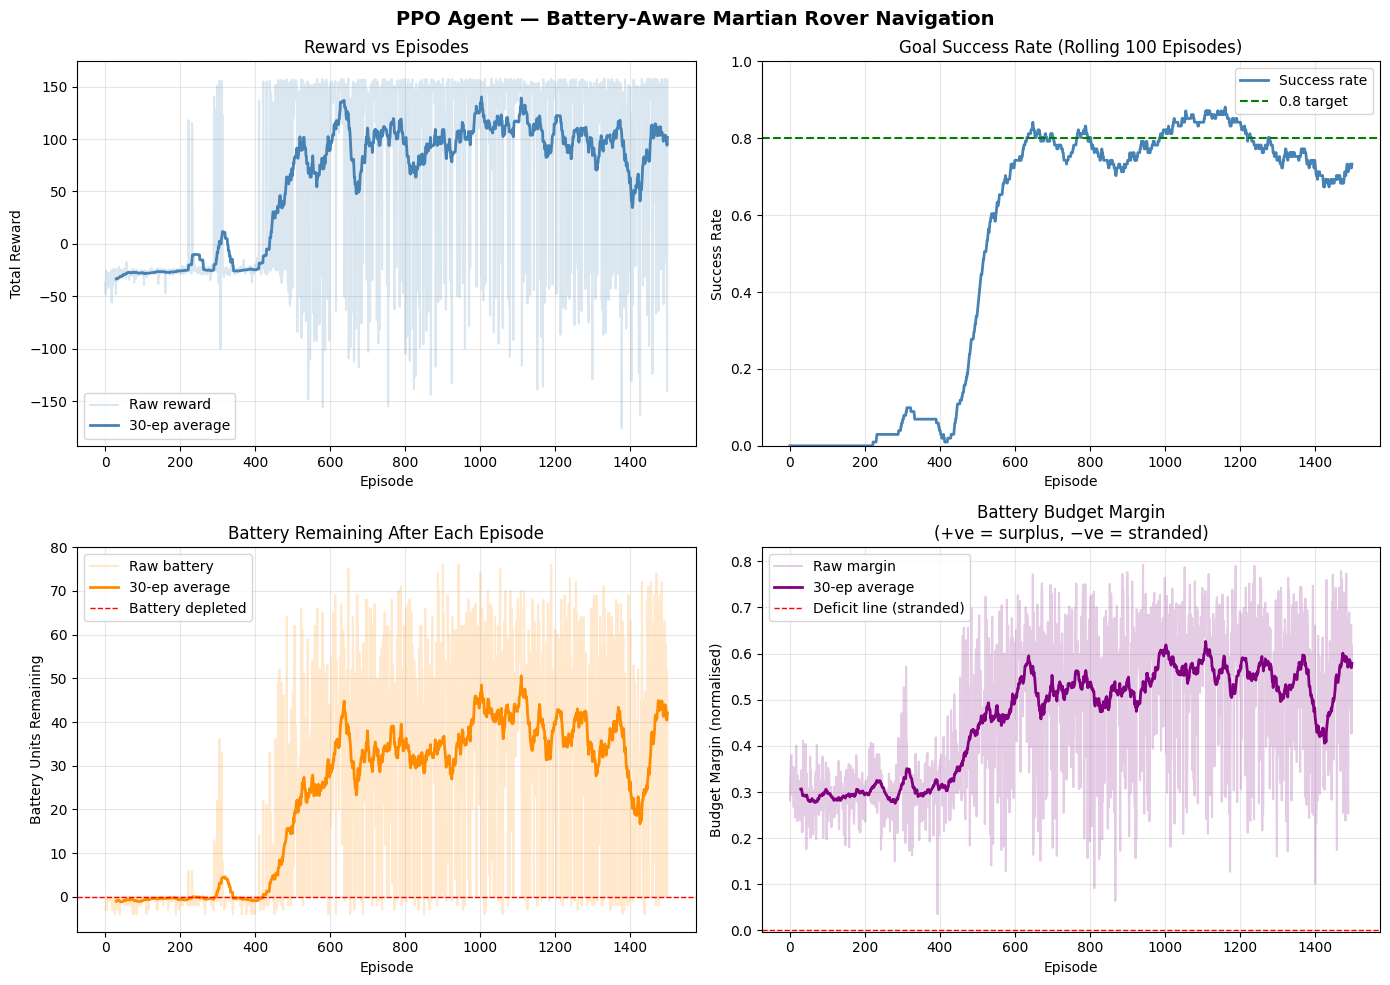

Saved: PPO_Training_Results.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

with open("ppo_results.pkl", "rb") as f:
    ppo = pickle.load(f)

def smooth(arr, w=30):
    return np.convolve(arr, np.ones(w)/w, mode='valid')

W = 30
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("PPO Agent — Battery-Aware Martian Rover Navigation",
             fontsize=14, fontweight='bold')

# 1. Reward vs Episodes
ax = axes[0, 0]
ax.plot(ppo["rewards"], alpha=0.2, color="steelblue", label="Raw reward")
ax.plot(range(W-1, len(ppo["rewards"])), smooth(ppo["rewards"], W),
        color="steelblue", lw=2, label="30-ep average")
ax.set_title("Reward vs Episodes")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
ax.legend()
ax.grid(alpha=0.3)

# 2. Success Rate
ax = axes[0, 1]
rolling_sr = [np.mean(ppo["success"][max(0,i-100):i+1])
              for i in range(len(ppo["success"]))]
ax.plot(rolling_sr, color="steelblue", lw=2, label="Success rate")
ax.axhline(0.8, color="green", linestyle="--", lw=1.5, label="0.8 target")
ax.set_title("Goal Success Rate (Rolling 100 Episodes)")
ax.set_xlabel("Episode")
ax.set_ylabel("Success Rate")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)

# 3. Battery Remaining
ax = axes[1, 0]
ax.plot(ppo["battery"], alpha=0.2, color="darkorange", label="Raw battery")
ax.plot(range(W-1, len(ppo["battery"])), smooth(ppo["battery"], W),
        color="darkorange", lw=2, label="30-ep average")
ax.axhline(0, color="red", linestyle="--", lw=1, label="Battery depleted")
ax.set_title("Battery Remaining After Each Episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Battery Units Remaining")
ax.legend()
ax.grid(alpha=0.3)

# 4. Budget Margin
ax = axes[1, 1]
ax.plot(ppo["margins"], alpha=0.2, color="purple", label="Raw margin")
ax.plot(range(W-1, len(ppo["margins"])), smooth(ppo["margins"], W),
        color="purple", lw=2, label="30-ep average")
ax.axhline(0, color="red", linestyle="--", lw=1, label="Deficit line (stranded)")
ax.set_title("Battery Budget Margin\n(+ve = surplus, −ve = stranded)")
ax.set_xlabel("Episode")
ax.set_ylabel("Budget Margin (normalised)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("PPO_Training_Results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: PPO_Training_Results.png")

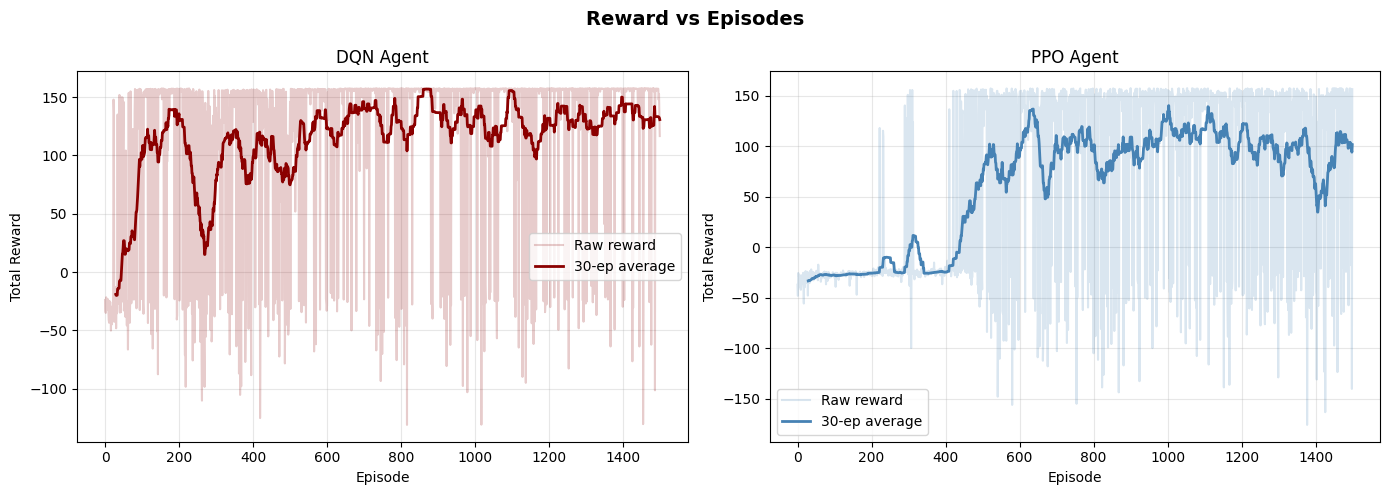

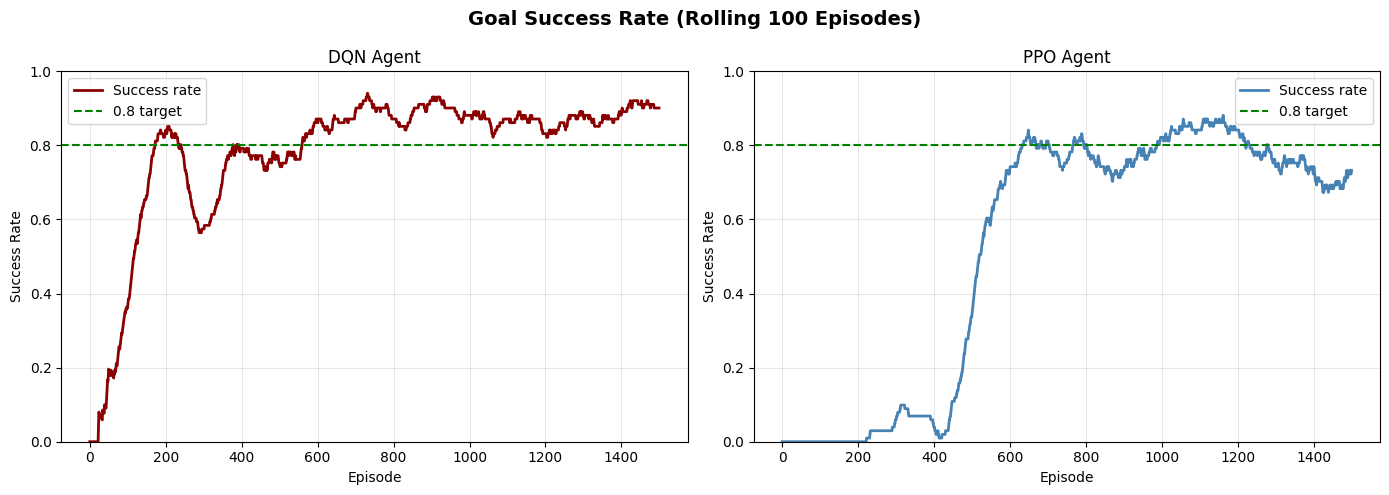

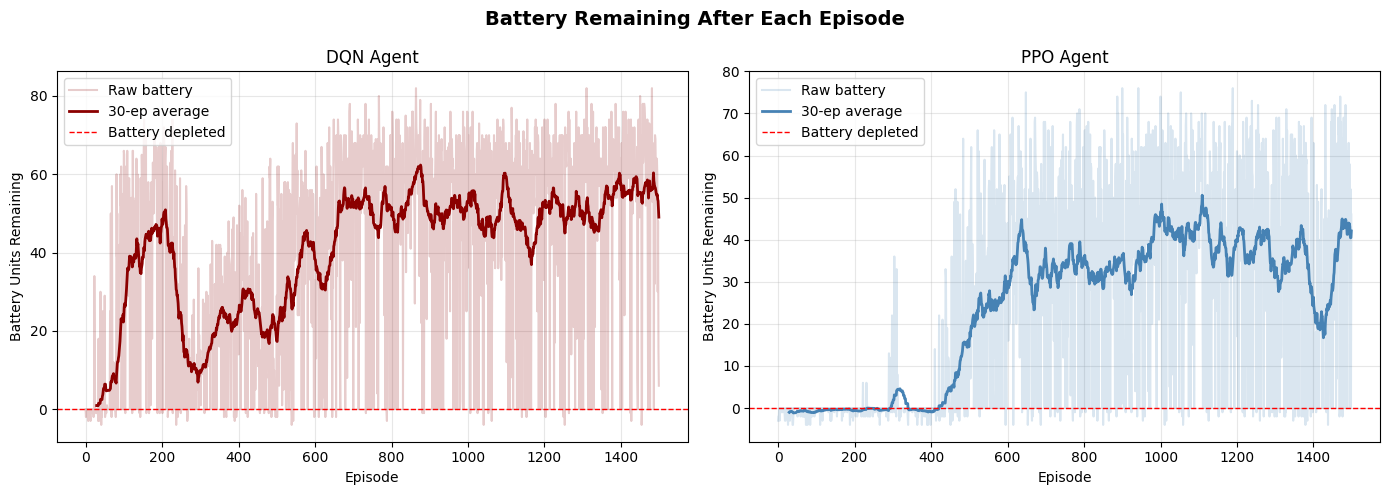

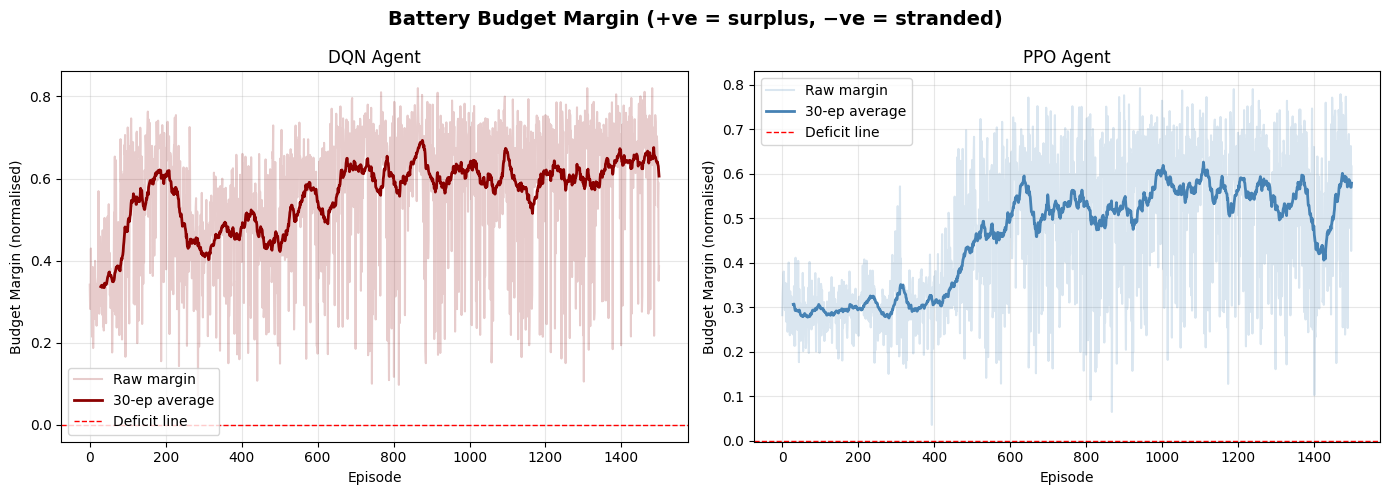

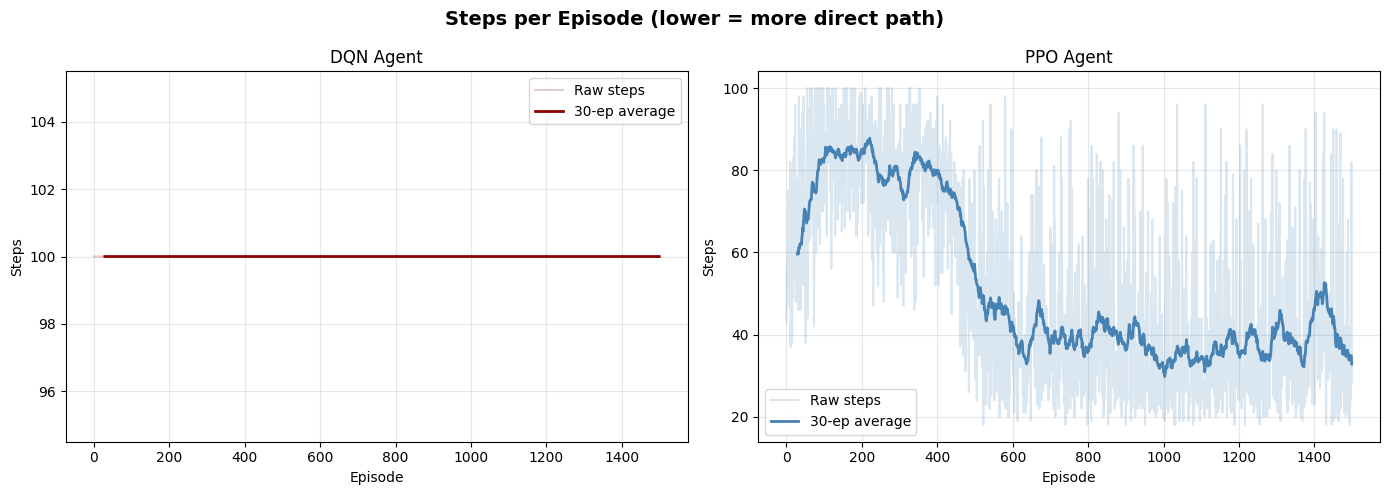

Saved: compare_reward.png, compare_success_rate.png,
       compare_battery.png, compare_budget_margin.png, compare_steps.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

with open("dqn_results.pkl", "rb") as f:
    dqn = pickle.load(f)

with open("ppo_results.pkl", "rb") as f:
    ppo = pickle.load(f)

def smooth(arr, w=30):
    return np.convolve(arr, np.ones(w)/w, mode='valid')

def rolling(arr, w=100):
    return [np.mean(arr[max(0,i-w):i+1]) for i in range(len(arr))]

W = 30

# ── Figure 1: Reward vs Episodes ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Reward vs Episodes", fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(dqn["rewards"], alpha=0.2, color="darkred", label="Raw reward")
ax.plot(range(W-1, len(dqn["rewards"])), smooth(dqn["rewards"], W),
        color="darkred", lw=2, label="30-ep average")
ax.set_title("DQN Agent")
ax.set_xlabel("Episode"); ax.set_ylabel("Total Reward")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(ppo["rewards"], alpha=0.2, color="steelblue", label="Raw reward")
ax.plot(range(W-1, len(ppo["rewards"])), smooth(ppo["rewards"], W),
        color="steelblue", lw=2, label="30-ep average")
ax.set_title("PPO Agent")
ax.set_xlabel("Episode"); ax.set_ylabel("Total Reward")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("compare_reward.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Success Rate ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Goal Success Rate (Rolling 100 Episodes)", fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(rolling(dqn["success"]), color="darkred", lw=2, label="Success rate")
ax.axhline(0.8, color="green", linestyle="--", lw=1.5, label="0.8 target")
ax.set_title("DQN Agent")
ax.set_xlabel("Episode"); ax.set_ylabel("Success Rate")
ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(rolling(ppo["success"]), color="steelblue", lw=2, label="Success rate")
ax.axhline(0.8, color="green", linestyle="--", lw=1.5, label="0.8 target")
ax.set_title("PPO Agent")
ax.set_xlabel("Episode"); ax.set_ylabel("Success Rate")
ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("compare_success_rate.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: Battery Remaining ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Battery Remaining After Each Episode", fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(dqn["battery"], alpha=0.2, color="darkred", label="Raw battery")
ax.plot(range(W-1, len(dqn["battery"])), smooth(dqn["battery"], W),
        color="darkred", lw=2, label="30-ep average")
ax.axhline(0, color="red", linestyle="--", lw=1, label="Battery depleted")
ax.set_title("DQN Agent")
ax.set_xlabel("Episode"); ax.set_ylabel("Battery Units Remaining")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(ppo["battery"], alpha=0.2, color="steelblue", label="Raw battery")
ax.plot(range(W-1, len(ppo["battery"])), smooth(ppo["battery"], W),
        color="steelblue", lw=2, label="30-ep average")
ax.axhline(0, color="red", linestyle="--", lw=1, label="Battery depleted")
ax.set_title("PPO Agent")
ax.set_xlabel("Episode"); ax.set_ylabel("Battery Units Remaining")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("compare_battery.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 4: Budget Margin ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Battery Budget Margin (+ve = surplus, −ve = stranded)",
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(dqn["margins"], alpha=0.2, color="darkred", label="Raw margin")
ax.plot(range(W-1, len(dqn["margins"])), smooth(dqn["margins"], W),
        color="darkred", lw=2, label="30-ep average")
ax.axhline(0, color="red", linestyle="--", lw=1, label="Deficit line")
ax.set_title("DQN Agent")
ax.set_xlabel("Episode"); ax.set_ylabel("Budget Margin (normalised)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(ppo["margins"], alpha=0.2, color="steelblue", label="Raw margin")
ax.plot(range(W-1, len(ppo["margins"])), smooth(ppo["margins"], W),
        color="steelblue", lw=2, label="30-ep average")
ax.axhline(0, color="red", linestyle="--", lw=1, label="Deficit line")
ax.set_title("PPO Agent")
ax.set_xlabel("Episode"); ax.set_ylabel("Budget Margin (normalised)")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("compare_budget_margin.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 5: Steps per Episode ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Steps per Episode (lower = more direct path)",
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(dqn["steps"], alpha=0.2, color="darkred", label="Raw steps")
ax.plot(range(W-1, len(dqn["steps"])), smooth(dqn["steps"], W),
        color="darkred", lw=2, label="30-ep average")
ax.set_title("DQN Agent")
ax.set_xlabel("Episode"); ax.set_ylabel("Steps")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(ppo["steps"], alpha=0.2, color="steelblue", label="Raw steps")
ax.plot(range(W-1, len(ppo["steps"])), smooth(ppo["steps"], W),
        color="steelblue", lw=2, label="30-ep average")
ax.set_title("PPO Agent")
ax.set_xlabel("Episode"); ax.set_ylabel("Steps")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("compare_steps.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: compare_reward.png, compare_success_rate.png,")
print("       compare_battery.png, compare_budget_margin.png, compare_steps.png")

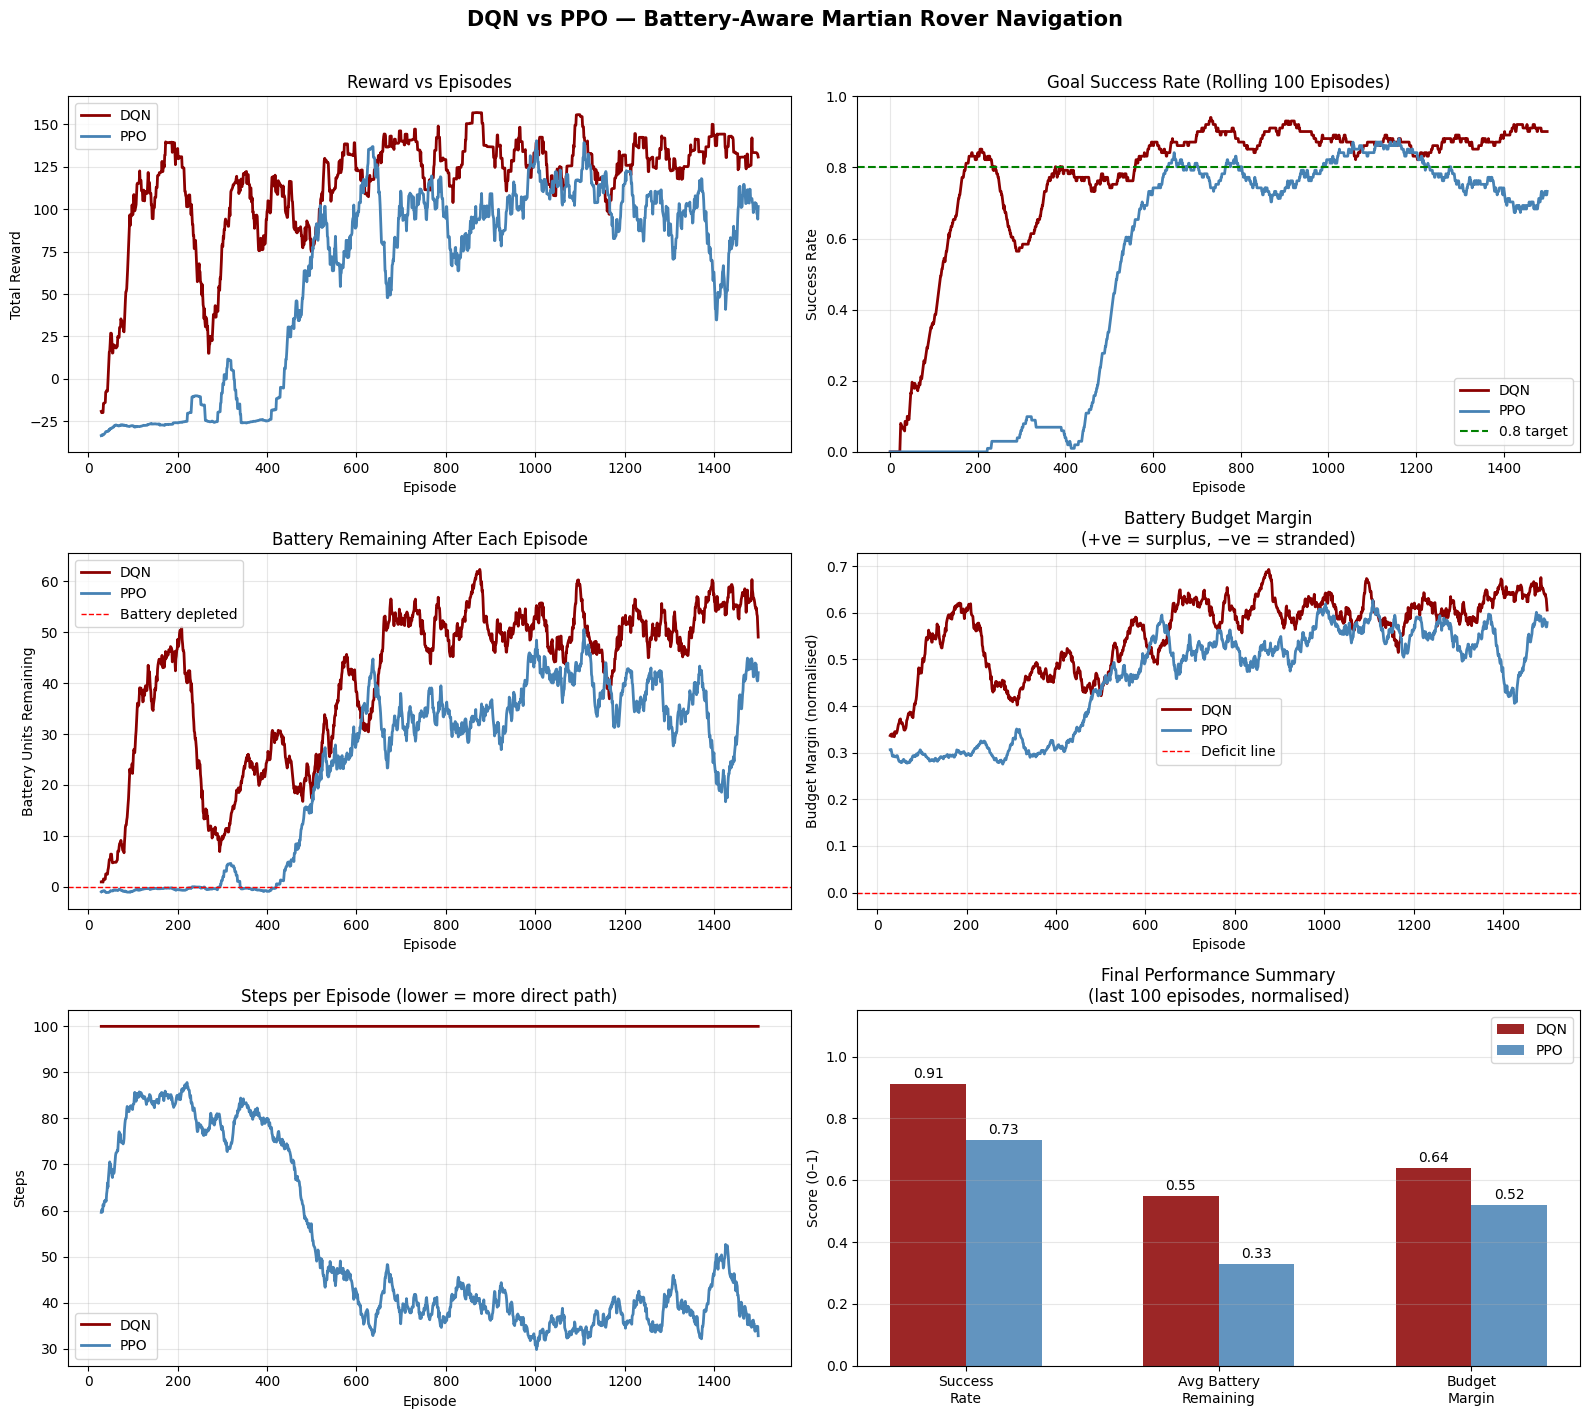

Saved: DQN_vs_PPO_Overlapping.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

with open("dqn_results.pkl", "rb") as f:
    dqn = pickle.load(f)

with open("ppo_results.pkl", "rb") as f:
    ppo = pickle.load(f)

def smooth(arr, w=30):
    return np.convolve(arr, np.ones(w)/w, mode='valid')

def rolling(arr, w=100):
    return [np.mean(arr[max(0,i-w):i+1]) for i in range(len(arr))]

W = 30
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("DQN vs PPO — Battery-Aware Martian Rover Navigation",
             fontsize=15, fontweight='bold', y=1.01)

# ── 1. Reward vs Episodes ──────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(range(W-1, len(dqn["rewards"])), smooth(dqn["rewards"], W),
        color="darkred", lw=2, label="DQN")
ax.plot(range(W-1, len(ppo["rewards"])), smooth(ppo["rewards"], W),
        color="steelblue", lw=2, label="PPO")
ax.set_title("Reward vs Episodes")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
ax.legend()
ax.grid(alpha=0.3)

# ── 2. Success Rate ────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(rolling(dqn["success"]), color="darkred",   lw=2, label="DQN")
ax.plot(rolling(ppo["success"]), color="steelblue", lw=2, label="PPO")
ax.axhline(0.8, color="green", linestyle="--", lw=1.5, label="0.8 target")
ax.set_title("Goal Success Rate (Rolling 100 Episodes)")
ax.set_xlabel("Episode")
ax.set_ylabel("Success Rate")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)

# ── 3. Battery Remaining ───────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(range(W-1, len(dqn["battery"])), smooth(dqn["battery"], W),
        color="darkred", lw=2, label="DQN")
ax.plot(range(W-1, len(ppo["battery"])), smooth(ppo["battery"], W),
        color="steelblue", lw=2, label="PPO")
ax.axhline(0, color="red", linestyle="--", lw=1, label="Battery depleted")
ax.set_title("Battery Remaining After Each Episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Battery Units Remaining")
ax.legend()
ax.grid(alpha=0.3)

# ── 4. Budget Margin ───────────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(range(W-1, len(dqn["margins"])), smooth(dqn["margins"], W),
        color="darkred", lw=2, label="DQN")
ax.plot(range(W-1, len(ppo["margins"])), smooth(ppo["margins"], W),
        color="steelblue", lw=2, label="PPO")
ax.axhline(0, color="red", linestyle="--", lw=1, label="Deficit line")
ax.set_title("Battery Budget Margin\n(+ve = surplus, −ve = stranded)")
ax.set_xlabel("Episode")
ax.set_ylabel("Budget Margin (normalised)")
ax.legend()
ax.grid(alpha=0.3)

# ── 5. Steps per Episode ───────────────────────────────────────────────────────
ax = axes[2, 0]
ax.plot(range(W-1, len(dqn["steps"])), smooth(dqn["steps"], W),
        color="darkred", lw=2, label="DQN")
ax.plot(range(W-1, len(ppo["steps"])), smooth(ppo["steps"], W),
        color="steelblue", lw=2, label="PPO")
ax.set_title("Steps per Episode (lower = more direct path)")
ax.set_xlabel("Episode")
ax.set_ylabel("Steps")
ax.legend()
ax.grid(alpha=0.3)

# ── 6. Summary bar chart ───────────────────────────────────────────────────────
ax = axes[2, 1]
last = 100
metrics   = ["Success\nRate", "Avg Battery\nRemaining", "Budget\nMargin"]
dqn_vals  = [
    round(np.mean(dqn["success"][-last:]), 2),
    round(np.mean(dqn["battery"][-last:]) / 100, 2),   # normalise to 0-1
    round(np.mean(dqn["margins"][-last:]), 2)
]
ppo_vals  = [
    round(np.mean(ppo["success"][-last:]), 2),
    round(np.mean(ppo["battery"][-last:]) / 100, 2),
    round(np.mean(ppo["margins"][-last:]), 2)
]

x     = np.arange(len(metrics))
width = 0.3
bars1 = ax.bar(x - width/2, dqn_vals, width, label="DQN", color="darkred",   alpha=0.85)
bars2 = ax.bar(x + width/2, ppo_vals, width, label="PPO", color="steelblue", alpha=0.85)

# value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=10)

ax.set_title("Final Performance Summary\n(last 100 episodes, normalised)")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score (0–1)")
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("DQN_vs_PPO_Overlapping.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: DQN_vs_PPO_Overlapping.png")

In [23]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


class MarsGridGenerator:

    NORMAL   = 0
    SAND     = 1
    ROCK     = 2
    OBSTACLE = 3

    def __init__(self, size=10):
        self.size = size

    # create clustered terrain patches
    def create_cluster(self, grid, terrain, count, cluster_size):

        for _ in range(count):

            x = random.randint(0, self.size-1)
            y = random.randint(0, self.size-1)

            for _ in range(cluster_size):

                dx = random.choice([-1,0,1])
                dy = random.choice([-1,0,1])

                nx = np.clip(x + dx, 0, self.size-1)
                ny = np.clip(y + dy, 0, self.size-1)

                grid[nx, ny] = terrain

                x, y = nx, ny

    def generate(self):

        grid = np.zeros((self.size, self.size), dtype=int)

        # sand patches
        self.create_cluster(grid, self.SAND, count=4, cluster_size=6)

        # rock patches
        self.create_cluster(grid, self.ROCK, count=3, cluster_size=5)

        # obstacle blocks
        self.create_cluster(grid, self.OBSTACLE, count=3, cluster_size=4)

        # random start and goal
        start = (0, 0)
        goal = (self.size-1, self.size-1)

        while True:
            start = (
                random.randint(0,self.size-1),
                random.randint(0,self.size-1)
            )
            if grid[start] != self.OBSTACLE:
                break

        while True:
            goal = (
                random.randint(0,self.size-1),
                random.randint(0,self.size-1)
            )
            if grid[goal] != self.OBSTACLE and goal != start:
                break

        grid[start] = self.NORMAL
        grid[goal] = self.NORMAL

        return grid, start, goal

In [33]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

def plot_mars(grid, start, goal, path=None, title="Rover Navigation Path"):

    # terrain colors
    colors = [
        "#d9d9d9",  # normal
        "#f4a460",  # sand
        "#808080",  # rock
        "#000000"   # obstacle
    ]

    cmap = mcolors.ListedColormap(colors)

    plt.figure(figsize=(6,6))
    plt.imshow(grid, cmap=cmap)

    # start
    plt.scatter(start[1], start[0],
                c='green', s=160, edgecolors='black')

    # goal
    plt.scatter(goal[1], goal[0],
                c='orange', s=160, edgecolors='black')

    # rover path
    if path is not None:
        y = [p[0] for p in path]
        x = [p[1] for p in path]

        plt.plot(x, y,
                 color="blue",
                 linewidth=2,
                 marker="o",
                 markersize=4)

    # legend items
    legend_elements = [
        Patch(facecolor="#d9d9d9", edgecolor='black', label='Normal Terrain'),
        Patch(facecolor="#f4a460", edgecolor='black', label='Sand'),
        Patch(facecolor="#808080", edgecolor='black', label='Rock'),
        Patch(facecolor="#000000", edgecolor='black', label='Obstacle'),
        plt.Line2D([0],[0], marker='o', color='w',
                   markerfacecolor='green', markeredgecolor='black',
                   markersize=10, label='Start'),
        plt.Line2D([0],[0], marker='o', color='w',
                   markerfacecolor='orange', markeredgecolor='black',
                   markersize=10, label='Goal'),
        plt.Line2D([0],[0], color='blue', marker='o',
                   markersize=5, label='Rover Path')
    ]

    plt.legend(handles=legend_elements,
               bbox_to_anchor=(1.05, 1),
               loc='upper left')

    plt.xlabel("Grid X Position")
    plt.ylabel("Grid Y Position")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

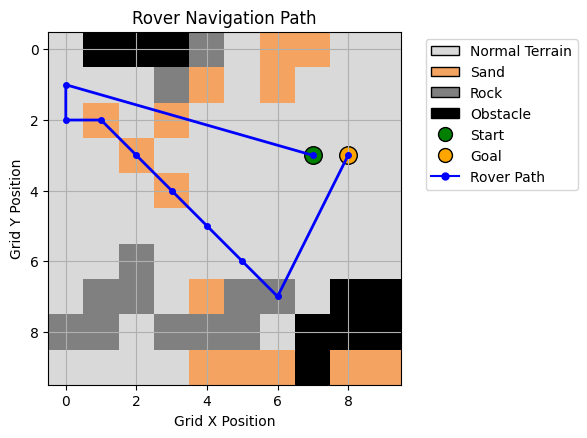

In [34]:
gen = MarsGridGenerator(size=10)
grid, start, goal = gen.generate()

path = [
    start,(1,0),(2,0),(2,1),(3,2),
    (4,3),(5,4),(6,5),(7,6),goal
]

plot_mars(grid, start, goal, path)

In [35]:
#Battery Heatmap Overlay (A* vs RL)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_battery_heatmap(
        grid,
        battery_map,
        start,
        goal,
        astar_path=None,
        rl_path=None,
        title="Battery-Aware Navigation: A* vs RL"
    ):

    fig, ax = plt.subplots(figsize=(7,6))

    # ---- terrain background ----
    terrain_colors = [
        "#f0f0f0",  # normal
        "#f4a460",  # sand
        "#808080",  # rock
        "#000000"   # obstacle
    ]

    terrain_cmap = mcolors.ListedColormap(terrain_colors)
    ax.imshow(grid, cmap=terrain_cmap, alpha=0.35)

    # ---- battery heatmap ----
    heat = ax.imshow(
        battery_map,
        cmap="viridis",
        alpha=0.85
    )

    # ---- A* path ----
    if astar_path is not None:
        y = [p[0] for p in astar_path]
        x = [p[1] for p in astar_path]

        ax.plot(
            x, y,
            color="red",
            linewidth=2.5,
            linestyle="--",
            marker="o",
            markersize=4
        )

    # ---- RL path ----
    if rl_path is not None:
        y = [p[0] for p in rl_path]
        x = [p[1] for p in rl_path]

        ax.plot(
            x, y,
            color="blue",
            linewidth=2.5,
            marker="o",
            markersize=4
        )

    # start / goal
    ax.scatter(start[1], start[0],
               c="green", s=180, edgecolors='black')

    ax.scatter(goal[1], goal[0],
               c="orange", s=180, edgecolors='black')

    # ---- colorbar ----
    cbar = plt.colorbar(heat, ax=ax)
    cbar.set_label("Remaining Battery Level")

    # ---- labels ----
    ax.set_xlabel("Grid X Coordinate")
    ax.set_ylabel("Grid Y Coordinate")

    # ---- legend ----
    legend_elements = [

        Patch(facecolor="#f0f0f0", edgecolor='black',
              label='Normal Terrain'),

        Patch(facecolor="#f4a460", edgecolor='black',
              label='Sand'),

        Patch(facecolor="#808080", edgecolor='black',
              label='Rock'),

        Patch(facecolor="#000000", edgecolor='black',
              label='Obstacle'),

        Line2D([0],[0], color="red", linestyle="--",
               marker='o', label="A* Path"),

        Line2D([0],[0], color="blue",
               marker='o', label="RL Path"),

        Line2D([0],[0], marker='o', color='w',
               markerfacecolor='green',
               markeredgecolor='black',
               markersize=10,
               label='Start'),

        Line2D([0],[0], marker='o', color='w',
               markerfacecolor='orange',
               markeredgecolor='black',
               markersize=10,
               label='Goal')
    ]

    ax.legend(
        handles=legend_elements,
        bbox_to_anchor=(1.05,1),
        loc="upper left"
    )

    ax.set_title(title)

    ax.grid(True, linewidth=0.3)

    plt.tight_layout()
    plt.show()

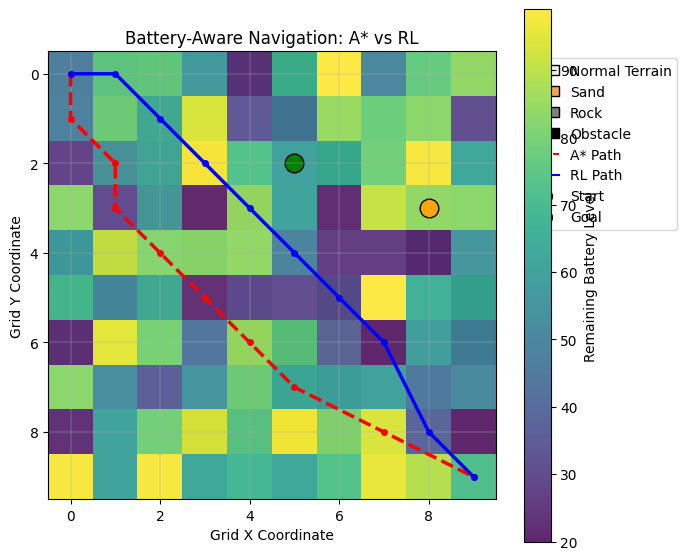

In [38]:
size = 10

grid, start, goal = MarsGridGenerator(size).generate()

# fake battery map example
battery_map = np.random.randint(20, 100, (size, size))

astar_path = [(0,0),(1,0),(2,1),(3,1),(4,2),(5,3),(6,4),(7,5),(8,7),(9,9)]
rl_path    = [(0,0),(0,1),(1,2),(2,3),(3,4),(4,5),(5,6),(6,7),(8,8),(9,9)]

plot_battery_heatmap(
    grid,
    battery_map,
    start,
    goal,
    astar_path,
    rl_path
)

In [42]:
def plot_battery_heatmap(
        grid,
        battery_map,
        start,
        goal,
        astar_path=None,
        rl_path=None,
        title="Battery-Aware Navigation: A* vs RL"
    ):

    fig, ax = plt.subplots(figsize=(7.5,6), constrained_layout=True)

    # terrain background
    terrain_colors = ["#f0f0f0","#f4a460","#808080","#000000"]
    terrain_cmap = mcolors.ListedColormap(terrain_colors)

    ax.imshow(grid, cmap=terrain_cmap, alpha=0.35)

    # gradient heatmap
    heat = ax.imshow(
        battery_map,
        cmap="viridis",
        interpolation="bicubic",
        alpha=0.9,
        vmin=0,
        vmax=100
    )

    # A* path
    if astar_path:
        y = [p[0] for p in astar_path]
        x = [p[1] for p in astar_path]

        ax.plot(x,y,
                color="red",
                linestyle="--",
                linewidth=2,
                marker="o",
                markersize=4)

    # RL path
    if rl_path:
        y = [p[0] for p in rl_path]
        x = [p[1] for p in rl_path]

        ax.plot(x,y,
                color="blue",
                linewidth=2,
                marker="o",
                markersize=4)

    # start goal
    ax.scatter(start[1], start[0], c="green", s=160, edgecolors='black')
    ax.scatter(goal[1], goal[0], c="orange", s=160, edgecolors='black')

    # colorbar
    cbar = fig.colorbar(heat, ax=ax, shrink=0.85)
    cbar.set_label("Remaining Battery Level")

    # labels
    ax.set_xlabel("Grid X Coordinate")
    ax.set_ylabel("Grid Y Coordinate")

    # legend
    legend_elements = [
        Patch(facecolor="#f0f0f0", edgecolor='black', label='Normal'),
        Patch(facecolor="#f4a460", edgecolor='black', label='Sand'),
        Patch(facecolor="#808080", edgecolor='black', label='Rock'),
        Patch(facecolor="#000000", edgecolor='black', label='Obstacle'),
        Line2D([0],[0], color="red", linestyle="--", marker='o', label="A* Path"),
        Line2D([0],[0], color="blue", marker='o', label="RL Path"),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='green',
               markeredgecolor='black', markersize=9, label='Start'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='orange',
               markeredgecolor='black', markersize=9, label='Goal')
    ]

    ax.legend(handles=legend_elements,
              loc="upper center",
              bbox_to_anchor=(0.5,-0.12),
              ncol=4)

    ax.set_title(title)
    ax.grid(True, linewidth=0.3)
    plt.savefig("Battery Heatmap: RL vs A*.png")
    plt.show()

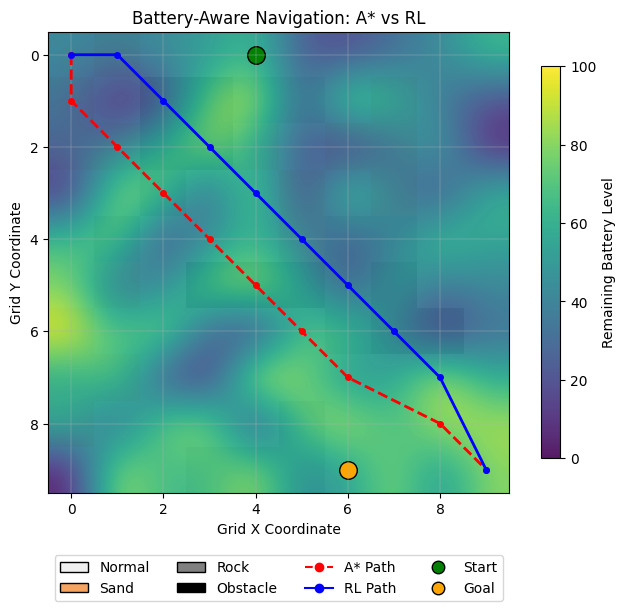

In [43]:
size = 10

grid, start, goal = MarsGridGenerator(size).generate()

battery_map = np.random.randint(0,100,(size,size))

astar_path = [(0,0),(1,0),(2,1),(3,2),(4,3),(5,4),(6,5),(7,6),(8,8),(9,9)]
rl_path    = [(0,0),(0,1),(1,2),(2,3),(3,4),(4,5),(5,6),(6,7),(7,8),(9,9)]

plot_battery_heatmap(
    grid,
    battery_map,
    start,
    goal,
    astar_path,
    rl_path
)